In [2]:
from transformers import BertForQuestionAnswering
from transformers import BertTokenizer
import torch

In [3]:
model_name = 'bert-large-uncased-whole-word-masking-finetuned-squad'

In [10]:
model = BertForQuestionAnswering.from_pretrained(model_name)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertForQuestionAnswering LOAD REPORT from: bert-large-uncased-whole-word-masking-finetuned-squad
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [11]:
tokenizer = BertTokenizer.from_pretrained(model_name)

In [15]:
question = 'when was the first dvd released'
answer_document = 'The first dvd was invented in 24 March,1997. It was a movie title \'teister\' and was released in japan'

In [31]:
encoding = tokenizer(text = question, text_pair=answer_document, 
                    return_tensors='pt', padding=True, truncation=True)

In [32]:
print(encoding)

{'input_ids': tensor([[  101,  2043,  2001,  1996,  2034,  4966,  2207,   102,  1996,  2034,
          4966,  2001,  8826,  1999,  2484,  2233,  1010,  2722,  1012,  2009,
          2001,  1037,  3185,  2516,  1005,  8915, 12911,  1005,  1998,  2001,
          2207,  1999,  2900,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


In [19]:
encoding = tokenizer(text = question, text_pair=answer_document)

In [20]:
print(encoding)

{'input_ids': [101, 2043, 2001, 1996, 2034, 4966, 2207, 102, 1996, 2034, 4966, 2001, 8826, 1999, 2484, 2233, 1010, 2722, 1012, 2009, 2001, 1037, 3185, 2516, 1005, 8915, 12911, 1005, 1998, 2001, 2207, 1999, 2900, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [41]:
input_ids = encoding['input_ids'][0]
sentence_embedding = encoding['token_type_ids' ] 
tokens = tokenizer.convert_ids_to_tokens(input_ids.tolist())


In [42]:
print(input_ids)

tensor([  101,  2043,  2001,  1996,  2034,  4966,  2207,   102,  1996,  2034,
         4966,  2001,  8826,  1999,  2484,  2233,  1010,  2722,  1012,  2009,
         2001,  1037,  3185,  2516,  1005,  8915, 12911,  1005,  1998,  2001,
         2207,  1999,  2900,   102])


In [43]:
tokenizer.decode(102)

'[SEP]'

In [48]:
tokenizer.decode(1723)

'マ'

In [53]:
output = model(
    input_ids=torch.tensor(inputs, dtype=torch.long),  # Use long dtype for input_ids
    token_type_ids=torch.tensor(sentence_embedding, dtype=torch.long)  # Use long dtype and correct parameter name
)


C:\Users\User\AppData\Local\Temp\ipykernel_28728\472581501.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids=torch.tensor(inputs, dtype=torch.long),  # Use long dtype for input_ids
C:\Users\User\AppData\Local\Temp\ipykernel_28728\472581501.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  token_type_ids=torch.tensor(sentence_embedding, dtype=torch.long)  # Use long dtype and correct parameter name


In [56]:
start_index = torch.argmax(output.start_logits)
end_index = torch.argmax(output.end_logits)
print(start_index)
print(end_index)

tensor(14)
tensor(17)


In [59]:
answer = ''.join(tokens[start_index:end_index+1])
print(answer)

24march,1997


In [60]:
import matplotlib as plt
import seaborn as sns

In [61]:
s_scores = output.start_logits.detach().numpy().flatten()
e_scores = output.end_logits.detach().numpy().flatten() 
token_labels = []
for (i, token) in enumerate(tokens):
    token_labels.append('{:} - {:>2}'.format(token, i))

C:\Users\User\AppData\Local\Temp\ipykernel_28728\1498777013.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")


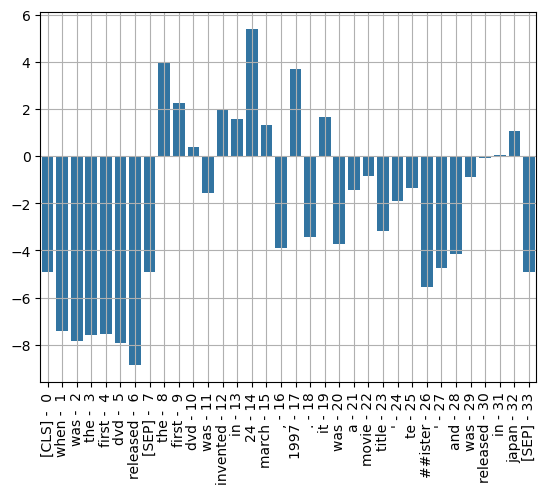

In [62]:
ax = sns.barplot(x=token_labels, y=s_scores) 
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center") 
ax.grid(True)